<a href="https://colab.research.google.com/github/Amirhossain959/geemap/blob/master/flood_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
!pip install --upgrade xee
!pip install -U geemap

In [35]:
import ee
import geemap
import os
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [36]:
ee.Authenticate()
ee.Initialize(
    project= 'roads-and-highways',
    opt_url= 'https://earthengine-highvolume.googleapis.com'
)

In [37]:
Map=geemap.Map()
Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [38]:
roi= Map.draw_last_feature.geometry()

In [39]:
time_start= ee.Date('2000')
time_end= ee.Date('2018')
time_diff= time_end.difference(time_start, 'month').round()
time_list= ee.List.sequence(0, time_diff).map(lambda t: time_start.advance(t, 'month'))
time_list

In [46]:
flooded= (
    ee.ImageCollection("GLOBAL_FLOOD_DB/MODIS_EVENTS/V1")
    .select('flooded')
    .filterDate(time_start, time_end)
)


permanent_water = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence').gt(60)

# flood_mask= flooded.map(lambda img:img.updateMask(permanent_water.Not()))



In [54]:
climate_bands = ['aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs']
climate= (
    ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE")
    .filterDate(time_start, time_end)
    .select(climate_bands)
)

In [48]:
all_bands= climate.first().bandNames().getInfo() + flooded.first().bandNames().getInfo()
all_bands

['aet',
 'def',
 'pdsi',
 'pet',
 'pr',
 'ro',
 'soil',
 'srad',
 'swe',
 'tmmn',
 'tmmx',
 'vap',
 'vpd',
 'vs',
 'flooded']

In [57]:
all_bands= ['aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs','flooded']

def create_homogenized_monthly_image(date_millis):
  start_date = ee.Date(date_millis)
  end_date = start_date.advance(1, 'month')

  # Create a template image with all expected bands filled with masked zeros, and explicitly cast to float32
  template_bands_list = []
  for b in all_bands:
    template_bands_list.append(ee.Image.constant(0).updateMask(ee.Image.constant(0)).rename(b).toFloat())
  template_image = ee.Image.cat(template_bands_list)

  # Retrieve raw monthly images, already pre-selected globally
  # And cast them to float32 upon retrieval
  flood_monthly = flooded.filterDate(start_date, end_date).sum().toFloat()
  climate_monthly = climate.filterDate(start_date, end_date).median().toFloat()

  flood_bands= ['flooded']
  climate_bands= ['aet', 'def', 'pdsi', 'pet', 'pr', 'ro', 'soil', 'srad', 'swe', 'tmmn', 'tmmx', 'vap', 'vpd', 'vs']

    # Use ee.Algorithms.If to handle potential empty collections for dynamic data
  flooded_data = ee.Image(ee.Algorithms.If(
      flood_monthly.bandNames().size().gt(0),
      flood_monthly.select(flood_bands),
      template_image.select(flood_bands)
    ))
  climate_data= ee.Image(ee.Algorithms.If(
      climate_monthly.bandNames().size().gt(0),
      climate_monthly.select(climate_bands),
      template_image.select(climate_bands)
    ))
    # Combine all data into the template image, overwriting masked zeros with actual data
  combined_image= (
      template_image
      .addBands(flooded_data, None, True)
      .addBands(climate_data, None, True)
    )
  final_image= combined_image.select(all_bands).toFloat()
  return final_image.set('system:time_start', start_date.millis())

In [60]:
collection= ee.ImageCollection(time_list.map(create_homogenized_monthly_image))
collection

In [61]:
lc= (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .filterDate('2000', '2018')
    .select('LC_Type1')
    .mode()
)
surface_water= (
    ee.Image("JRC/GSW1_4/GlobalSurfaceWater")
    .select('occurrence')
)
dem= (
    ee.Image("NASA/NASADEM_HGT/001")
    .select('elevation')
)

In [62]:
collection=collection.map(
    lambda img:img.addBands(lc).addBands(surface_water).addBands(dem).updateMask(permanent_water.Not())

)
collection

In [63]:
ds= xr.open_dataset(
    collection,
    engine= 'ee',
    crs= 'epsg:4326',
    geometry= roi,
    scale= 0.1
)


In [64]:
ds= ds.sortby('time') * 1
ds

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 217, lon: 17, lat: 13)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2000-01-01 2000-02-01 ... 2018-01-01
  * lon         (lon) float64 136B 90.91 91.01 91.11 91.21 ... 92.31 92.41 92.51
  * lat         (lat) float64 104B 24.05 24.15 24.25 24.35 ... 25.05 25.15 25.25
Data variables: (12/18)
    aet         (time, lon, lat) float32 192kB 498.0 497.0 495.0 ... nan nan nan
    def         (time, lon, lat) float32 192kB 202.0 203.0 200.0 ... nan nan nan
    pdsi        (time, lon, lat) float32 192kB 264.0 262.0 257.0 ... nan nan nan
    pet         (time, lon, lat) float32 192kB 700.0 700.0 695.0 ... nan nan nan
    pr          (time, lon, lat) float32 192kB 36.0 36.0 37.0 ... nan nan nan
    ro          (time, lon, lat) float32 192kB 2.0 2.0 2.0 2.0 ... nan nan nan
    ...          ...
    vpd         (time, lon, lat) float32 192kB 68.0 70.0 70.0 ... nan nan nan
    vs          (time, lon, lat) float32 192kB 75.0 75.0 72.0 ... nan nan nan
    flooded     (time, lon, lat) float32 192kB nan nan nan nan ... nan nan nan
    LC_Type1    (time, lon, lat) float32 192kB 14.0 12.0 12.0 ... 2.0 2.0 nan
    occurrence  (time, lon, lat) float32 192kB 19.0 10.0 13.0 ... 9.0 25.0 nan
    elevation   (time, lon, lat) float32 192kB 9.0 8.0 7.0 ... 399.0 645.0 nan
Attributes:
    crs:      epsg:4326

In [66]:
ds1= ds.sel(time=slice('2015-01-01', '2017-12-01'))
ds1

<xarray.Dataset> Size: 573kB
Dimensions:     (time: 36, lon: 17, lat: 13)
Coordinates:
  * time        (time) datetime64[ns] 288B 2015-01-01 2015-02-01 ... 2017-12-01
  * lon         (lon) float64 136B 90.91 91.01 91.11 91.21 ... 92.31 92.41 92.51
  * lat         (lat) float64 104B 24.05 24.15 24.25 24.35 ... 25.05 25.15 25.25
Data variables: (12/18)
    aet         (time, lon, lat) float32 32kB 283.0 283.0 281.0 ... 441.0 nan
    def         (time, lon, lat) float32 32kB 403.0 404.0 399.0 ... 201.0 nan
    pdsi        (time, lon, lat) float32 32kB -427.0 -421.0 -416.0 ... 218.0 nan
    pet         (time, lon, lat) float32 32kB 686.0 686.0 681.0 ... 642.0 nan
    pr          (time, lon, lat) float32 32kB 9.0 9.0 9.0 9.0 ... 25.0 21.0 nan
    ro          (time, lon, lat) float32 32kB 0.0 0.0 0.0 0.0 ... 1.0 1.0 nan
    ...          ...
    vpd         (time, lon, lat) float32 32kB 70.0 71.0 72.0 ... 53.0 43.0 nan
    vs          (time, lon, lat) float32 32kB 75.0 75.0 71.0 ... 65.0 66.0 nan
    flooded     (time, lon, lat) float32 32kB nan nan nan nan ... nan nan nan
    LC_Type1    (time, lon, lat) float32 32kB 14.0 12.0 12.0 ... 2.0 2.0 nan
    occurrence  (time, lon, lat) float32 32kB 19.0 10.0 13.0 ... 9.0 25.0 nan
    elevation   (time, lon, lat) float32 32kB 9.0 8.0 7.0 ... 399.0 645.0 nan
Attributes:
    crs:      epsg:4326

In [73]:
df= ds1.to_dataframe()
df

aet    def   pdsi    pet    pr   ro    soil  \
time       lon       lat                                                       
2015-01-01 90.906351 24.04629  283.0  403.0 -427.0  686.0   9.0  0.0   569.0   
                     24.14629  283.0  404.0 -421.0  686.0   9.0  0.0   561.0   
                     24.24629  281.0  399.0 -416.0  681.0   9.0  0.0   557.0   
                     24.34629  284.0  402.0 -410.0  686.0   9.0  0.0   545.0   
                     24.44629  286.0  401.0 -405.0  687.0  10.0  0.0   542.0   
...                              ...    ...    ...    ...   ...  ...     ...   
2017-12-01 92.506351 24.84629  502.0  211.0  255.0  712.0  27.0  1.0  1434.0   
                     24.94629  504.0  207.0  250.0  710.0  28.0  1.0  1536.0   
                     25.04629  480.0  206.0  240.0  686.0  25.0  1.0  1589.0   
                     25.14629  441.0  201.0  218.0  642.0  21.0  1.0  1586.0   
                     25.24629    NaN    NaN    NaN    NaN   NaN  NaN     NaN   

                                 srad  swe   tmmn   tmmx     vap   vpd    vs  \
time       lon       lat                                                       
2015-01-01 90.906351 24.04629  1772.0  0.0  117.0  234.0  1444.0  70.0  75.0   
                     24.14629  1768.0  0.0  118.0  236.0  1436.0  71.0  75.0   
                     24.24629  1762.0  0.0  117.0  236.0  1435.0  72.0  71.0   
                     24.34629  1751.0  0.0  119.0  239.0  1432.0  76.0  73.0   
                     24.44629  1761.0  0.0  117.0  237.0  1430.0  73.0  78.0   
...                               ...  ...    ...    ...     ...   ...   ...   
2017-12-01 92.506351 24.84629  1705.0  0.0  146.0  265.0  1826.0  60.0  61.0   
                     24.94629  1703.0  0.0  147.0  265.0  1823.0  60.0  60.0   
                     25.04629  1690.0  0.0  135.0  247.0  1683.0  53.0  65.0   
                     25.14629  1660.0  0.0  120.0  222.0  1524.0  43.0  66.0   
                     25.24629     NaN  NaN    NaN    NaN     NaN   NaN   NaN   

                               flooded  LC_Type1  occurrence  elevation  
time       lon       lat                                                 
2015-01-01 90.906351 24.04629      NaN      14.0        19.0        9.0  
                     24.14629      NaN      12.0        10.0        8.0  
                     24.24629      NaN      12.0        13.0        7.0  
                     24.34629      NaN      10.0        41.0        6.0  
                     24.44629      NaN      12.0        37.0        7.0  
...                                ...       ...         ...        ...  
2017-12-01 92.506351 24.84629      NaN      12.0        32.0       29.0  
                     24.94629      NaN      12.0        39.0       17.0  
                     25.04629      NaN       2.0         9.0      399.0  
                     25.14629      NaN       2.0        25.0      645.0  
                     25.24629      NaN       NaN         NaN        NaN  

[7956 rows x 18 columns]

In [76]:
df.describe()


,aet,def,pdsi,pet,pr,ro,soil,srad,swe,tmmn,tmmx,vap,vpd,vs,flooded,LC_Type1,occurrence,elevation
count,7128.000000,7128.000000,7128.000000,7128.000000,7128.000000,7128.000000,7128.000000,7128.000000,7128.0,7128.000000,7128.000000,7128.000000,7128.000000,7128.000000,792.000000,7128.000000,7128.000000,7128.000000
mean,864.670593,153.332214,-144.631317,1017.951294,236.067062,148.440933,1338.651978,1962.466431,0.0,198.857330,295.513184,2470.192383,79.363495,106.615036,0.313131,9.904040,28.651516,82.914139
std,374.641296,219.758804,256.443054,225.447769,228.898880,199.751495,581.003601,250.658035,0.0,49.113796,29.701273,655.312378,19.071737,43.717625,0.464061,3.332932,16.562429,197.520889
min,180.000000,0.000000,-816.000000,556.000000,0.000000,0.000000,212.000000,1389.000000,0.0,84.000000,179.000000,1202.000000,25.000000,38.000000,0.000000,2.000000,3.000000,5.000000
25%,450.000000,0.000000,-338.000000,824.000000,21.000000,1.000000,848.750000,1774.000000,0.0,156.000000,276.000000,1811.750000,67.000000,72.000000,0.000000,9.000000,13.000000,8.000000
50%,1004.000000,0.000000,-212.000000,1050.000000,199.000000,16.000000,1505.000000,1925.000000,0.0,217.000000,309.000000,2621.000000,76.000000,98.000000,0.000000,12.000000,27.000000,14.500000
75%,1128.250000,303.000000,133.000000,1165.000000,383.250000,257.000000,1764.000000,2118.000000,0.0,244.000000,318.000000,3159.000000,91.000000,139.000000,1.000000,12.000000,43.000000,49.000000
max,1459.000000,1047.000000,403.000000,1459.000000,1800.000000,1693.000000,2608.000000,2613.000000,0.0,261.000000,334.000000,3321.000000,146.000000,301.000000,1.000000,14.000000,60.000000,1049.000000


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 7956 entries, (Timestamp('2015-01-01 00:00:00'), np.float64(90.906351), np.float64(24.04629)) to (Timestamp('2017-12-01 00:00:00'), np.float64(92.50635100000001), np.float64(25.24629))
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   aet         7128 non-null   float32
 1   def         7128 non-null   float32
 2   pdsi        7128 non-null   float32
 3   pet         7128 non-null   float32
 4   pr          7128 non-null   float32
 5   ro          7128 non-null   float32
 6   soil        7128 non-null   float32
 7   srad        7128 non-null   float32
 8   swe         7128 non-null   float32
 9   tmmn        7128 non-null   float32
 10  tmmx        7128 non-null   float32
 11  vap         7128 non-null   float32
 12  vpd         7128 non-null   float32
 13  vs          7128 non-null   float32
 14  flooded     792 non-null    float32
 15  LC_Type1    7128 non-null   fl

In [81]:
df.dropna(inplace=True)

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.linear_model import LogisticRegression, Perceptron, SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import time

from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import time

import tensorflow as tf
from tensorflow.keras.layers import Dense, Activation
# Dense Neural Network
from tensorflow.keras.layers import Dense, Dropout
# Sequential Connection with Neural Network
from tensorflow.keras.models import Sequential
# Optimizers for Regression Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, PReLU

#from tensorflow.keras.layers import PReLU, ELU, Activation
#from tensorflow.keras.layers import Dense, LeakyReLU
from keras.layers import Dense, Activation, LeakyReLU, PReLU, ELU

In [125]:
X = df.drop(columns=['flooded'], axis=1)
y = df['flooded']

In [126]:
# Split the dataset into training, testing, and validation sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [118]:
X_train.shape[1]

17

In [127]:
def build_model():
    # Sequential Neural Network - Feedforward Neural Network
    model = Sequential()
    # Units = Number of Neurons(2 * pow(n)) , Input Shape = Num of Features
    model.add(Dense(units = 64, activation = 'relu', input_shape = [len(X.keys())]))

    # Hidden Layer - I
    model.add(Dense(units = 128, activation = 'relu'))

    # Hidden Layer - II
    model.add(Dense(units = 128, activation = 'relu'))

    # Output Layer - For binary Classification
    model.add(Dense(units = 1, activation = 'sigmoid'))

    # Optimizers (alpha)
    optimizers = Adam(learning_rate = 0.001)

    # Model Compiler
    # Error Function for binary classification = 'binary_crossentropy'
    # Metrics = Metrics of Model / Check the performance of model is Accuracy
    model.compile(loss = 'binary_crossentropy', optimizer = optimizers, metrics = ['accuracy'])

    return model

In [128]:
model1 = build_model()

In [129]:
model1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,113 (102.00 KB)

 Trainable params: 26,113 (102.00 KB)

 Non-trainable params: 0 (0.00 B)

In [130]:
history1= model1.fit(X_train, y_train, epochs= 100, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5967 - loss: 48.0630 - val_accuracy: 0.6875 - val_loss: 6.3173
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6635 - loss: 4.7045 - val_accuracy: 0.6500 - val_loss: 3.6726
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6513 - loss: 3.6035 - val_accuracy: 0.7000 - val_loss: 1.7443
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6860 - loss: 2.2509 - val_accuracy: 0.6375 - val_loss: 2.2434
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6251 - loss: 3.6660 - val_accuracy: 0.6375 - val_loss: 1.6694
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7038 - loss: 1.5233 - val_accuracy: 0.6750 - val_loss: 3.6260
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6416 - loss: 3.4758 - val_accuracy: 0.6750 - val_loss: 5.5572
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7098 - loss: 2.8601 - val_accuracy: 0.68

<Axes: >

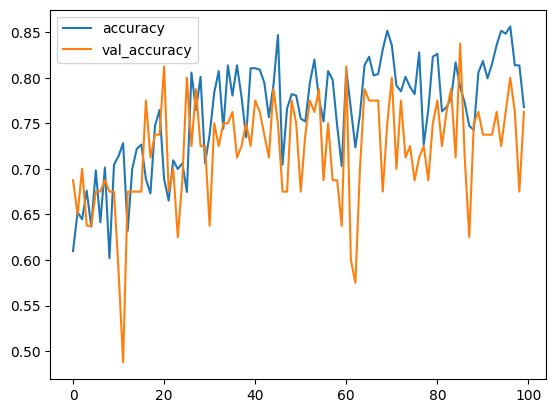

In [131]:
pd.DataFrame(history1.history)[['accuracy', 'val_accuracy']].plot()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


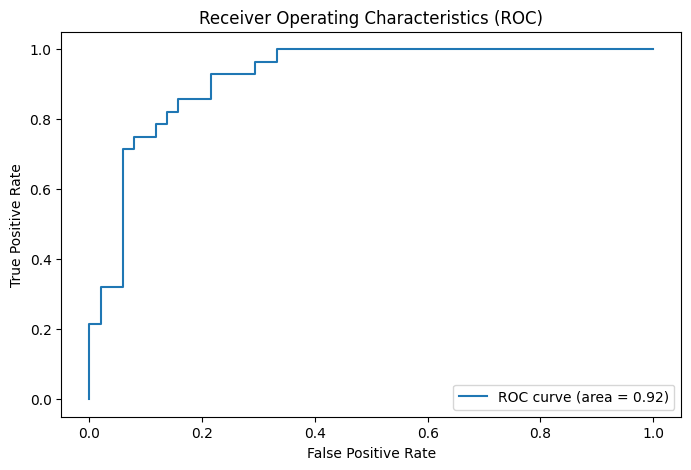

In [132]:
fpr = {}
tpr = {}
roc_auc = {}

# Get predicted probabilities for the positive class
y_test_prob = model1.predict(X_test)

# For binary classification, roc_curve expects 1D arrays
fpr['micro'], tpr['micro'], _ = roc_curve(y_test, y_test_prob)
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

plt.figure(figsize=(8,5))
plt.plot(fpr['micro'], tpr['micro'], label= 'ROC curve (area = {:.2f})'.format(roc_auc['micro']))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristics (ROC)')
plt.legend(loc='lower right')
plt.show()